# Assignment 3

## Learn an XOR Neural Network using gradient-based optimization

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-04-19

Course: Deep Machine Learning 4DT908

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Function definitions

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))


def mse_derivative(y_true, y_pred):
    n = y_true.size
    return (2 / n) * (y_pred - y_true)

### Init training data

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [0]])

### Init random weights & train network

In [4]:
np.random.seed(42)

input_size = 2
hidden_size = 5
output_size = 1

weights_1 = 0.1 * np.random.randn(input_size, hidden_size)
biases_1 = np.zeros((1, hidden_size))
weights_2 = 0.1 * np.random.randn(hidden_size, output_size)
biases_2 = np.zeros((1, output_size))

learning_rate = 3.0
epochs = 5000
losses = []

for epoch_idx in range(epochs):
    z_1 = X @ weights_1 + biases_1
    a_1 = sigmoid(z_1)
    z_2 = a_1 @ weights_2 + biases_2
    a_2 = sigmoid(z_2)

    loss_val = mse(Y, a_2)
    losses.append(loss_val)

    if epoch_idx % 1000 == 0 or epoch_idx == epochs - 1:
        print(f"Epoch {epoch_idx}, Loss: {loss_val:.5f}")

    dz_2 = mse_derivative(Y, a_2) * sigmoid_derivative(z_2)
    dw_2 = a_1.T @ dz_2
    db_2 = np.sum(dz_2, axis=0, keepdims=True)

    dz_1 = dz_2 @ weights_2.T * sigmoid_derivative(z_1)
    dw_1 = X.T @ dz_1
    db_1 = np.sum(dz_1, axis=0, keepdims=True)

    weights_2 -= learning_rate * dw_2
    biases_2 -= learning_rate * db_2
    weights_1 -= learning_rate * dw_1
    biases_1 -= learning_rate * db_1

Epoch 0, Loss: 0.25300
Epoch 1000, Loss: 0.25000
Epoch 2000, Loss: 0.24999
Epoch 3000, Loss: 0.02343
Epoch 4000, Loss: 0.00095


Epoch 4999, Loss: 0.00043


### Evaluate network


Final outputs after training:
[[0.]
 [1.]
 [1.]
 [0.]]


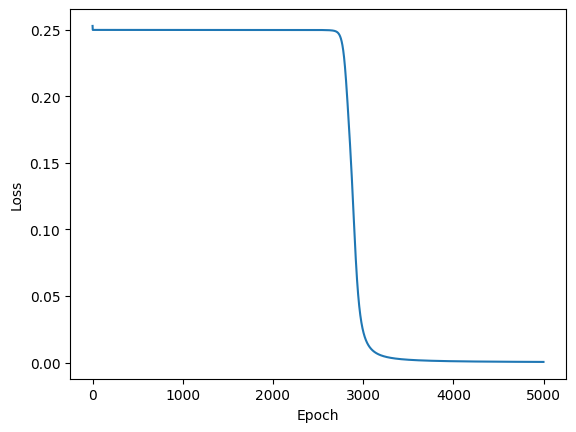

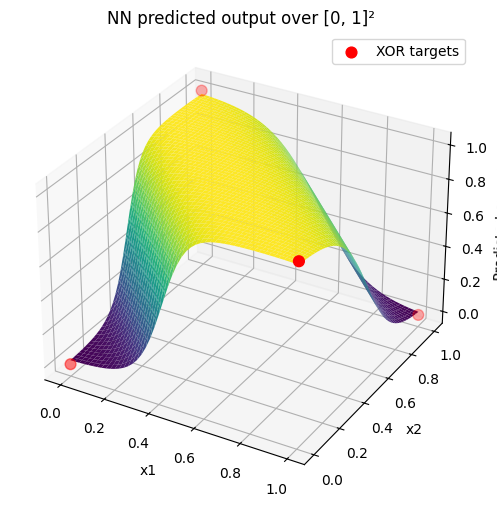

In [5]:
print("\nFinal outputs after training:")
z1 = X @ weights_1 + biases_1
a1 = sigmoid(z1)
z2 = a1 @ weights_2 + biases_2
a2 = sigmoid(z2)
print(np.round(a2))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 3-D plot of the NN's predicted output over the input square [0, 1]^2
x1_range = np.linspace(0, 1, 50)
x2_range = np.linspace(0, 1, 50)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])

a1_grid = sigmoid(X_grid @ weights_1 + biases_1)
a2_grid = sigmoid(a1_grid @ weights_2 + biases_2).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x1_grid, x2_grid, a2_grid, cmap="viridis")
ax.scatter(
    X[:, 0], X[:, 1], Y.ravel(),
    color="red", s=60, zorder=5, label="XOR targets"
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Predicted output")
ax.set_title("NN predicted output over [0, 1]\u00b2")
ax.legend()
plt.show()

### Loss-space visualisation

**How to plot the loss space when XOR is defined at four points?**

The total parameter space of this network is high-dimensional (all weights and
biases together), so it cannot be displayed directly.  A practical approach is
to pick two parameters of interest, sweep them over a grid while keeping every
other parameter fixed at its trained value, and then compute the MSE loss at
each grid point using the four XOR training samples.

Even though the XOR targets are only defined at the four corners
`{(0,0), (0,1), (1,0), (1,1)}`, the loss is a well-defined scalar for *any*
weight configuration: just forward-pass those four inputs through the network
and average the squared errors.  The cell below sweeps two weights in the
second layer and plots the resulting 2-D slice of the loss landscape.

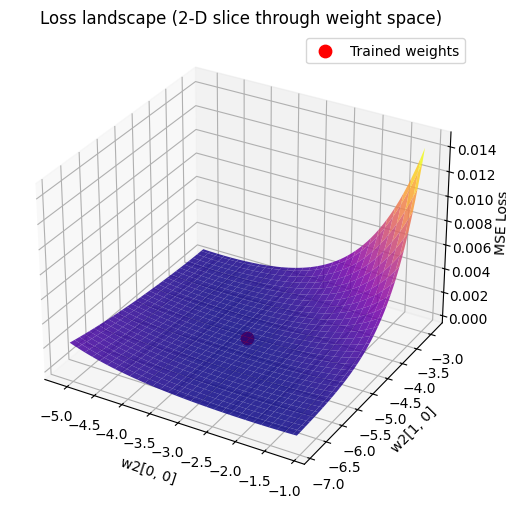

In [6]:
# 2-D slice of the loss landscape: vary two weights of the second layer
w_range = np.linspace(weights_2[0, 0] - 2.0, weights_2[0, 0] + 2.0, 60)
v_range = np.linspace(weights_2[1, 0] - 2.0, weights_2[1, 0] + 2.0, 60)
w0_grid, w1_grid = np.meshgrid(w_range, v_range)
loss_grid = np.zeros_like(w0_grid)

for i in range(w0_grid.shape[0]):
    for j in range(w0_grid.shape[1]):
        w2_tmp = np.copy(weights_2)
        w2_tmp[0, 0] = w0_grid[i, j]
        w2_tmp[1, 0] = w1_grid[i, j]
        a1_tmp = sigmoid(X @ weights_1 + biases_1)
        a2_tmp = sigmoid(a1_tmp @ w2_tmp + biases_2)
        loss_grid[i, j] = mse(Y, a2_tmp)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(w0_grid, w1_grid, loss_grid, cmap="plasma", alpha=0.85)
# Mark the trained weight position
trained_loss = mse(Y, sigmoid(sigmoid(X @ weights_1 + biases_1) @ weights_2 + biases_2))
ax.scatter(
    [weights_2[0, 0]], [weights_2[1, 0]], [trained_loss],
    color="red", s=80, zorder=5, label="Trained weights"
)
ax.set_xlabel("w2[0, 0]")
ax.set_ylabel("w2[1, 0]")
ax.set_zlabel("MSE Loss")
ax.set_title("Loss landscape (2-D slice through weight space)")
ax.legend()
plt.show()

### Verify gradients with PyTorch autodiff

In [7]:
import torch

X_t = torch.tensor(X, dtype=torch.float64)
Y_t = torch.tensor(Y, dtype=torch.float64)

w1_t = torch.tensor(weights_1, dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor(biases_1, dtype=torch.float64, requires_grad=True)
w2_t = torch.tensor(weights_2, dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(biases_2, dtype=torch.float64, requires_grad=True)

z1_t = X_t @ w1_t + b1_t
a1_t = torch.sigmoid(z1_t)
z2_t = a1_t @ w2_t + b2_t
a2_t = torch.sigmoid(z2_t)
loss_t = torch.mean((Y_t - a2_t) ** 2)

loss_t.backward()

z_1_v = X @ weights_1 + biases_1
a_1_v = sigmoid(z_1_v)
z_2_v = a_1_v @ weights_2 + biases_2
a_2_v = sigmoid(z_2_v)

dz_2_v = mse_derivative(Y, a_2_v) * sigmoid_derivative(z_2_v)
dw_2_manual = a_1_v.T @ dz_2_v
db_2_manual = np.sum(dz_2_v, axis=0, keepdims=True)
dz_1_v = dz_2_v @ weights_2.T * sigmoid_derivative(z_1_v)
dw_1_manual = X.T @ dz_1_v
db_1_manual = np.sum(dz_1_v, axis=0, keepdims=True)

print("Gradient verification:")
print(f"\tdw2 max abs diff: {np.max(np.abs(dw_2_manual - w2_t.grad.numpy())):.2e}")
print(f"\tdb2 max abs diff: {np.max(np.abs(db_2_manual - b2_t.grad.numpy())):.2e}")
print(f"\tdw1 max abs diff: {np.max(np.abs(dw_1_manual - w1_t.grad.numpy())):.2e}")
print(f"\tdb1 max abs diff: {np.max(np.abs(db_1_manual - b1_t.grad.numpy())):.2e}")

Gradient verification:
	dw2 max abs diff: 1.90e-19
	db2 max abs diff: 1.90e-19
	dw1 max abs diff: 2.44e-19
	db1 max abs diff: 2.17e-19


### Conclusion

The network successfully learned the XOR problem.
 
The network uses 2 input neurons, a hidden layer of 5 units, and 1 output neuron, all with sigmoid activations. Weights were initialised with small random values (scaled by 0.1) and biases at zero. Training ran for 5 000 epochs with a learning rate of 3.0 and mean-squared error (MSE) as the loss function.

As shown in the loss curve, the network made very little progress during the first ~3 000 epochs before converging rapidly. This is characteristic of gradient descent on non-convex loss landscapes.

The 3-D surface plot of the predicted output over the input square [0, 1]² shows the non-linear decision boundary the network has learned: outputs near 1 at (0, 1) and (1, 0) and outputs near 0 at (0, 0) and (1, 1).

The loss-landscape section demonstrates one way to visualise the loss space for a 4-point XOR function: sweep two weights of the second layer over a grid, compute the MSE on the four training samples at each grid point, and plot the result as a 3-D surface. The red dot marks where gradient descent converged.

The Gradient verification section confirms that the analytical back-propagation gradients match PyTorch autodiff to within numerical precision (differences < 1e–10).